<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

k0 = 0.09817477042468103
omega(k0 - dk) = 1.0053096491487339
omega(k0)      = 1.0053096491487339
omega(k0 + dk) = 1.0053096491487339
Estimated c_eff = 0.0


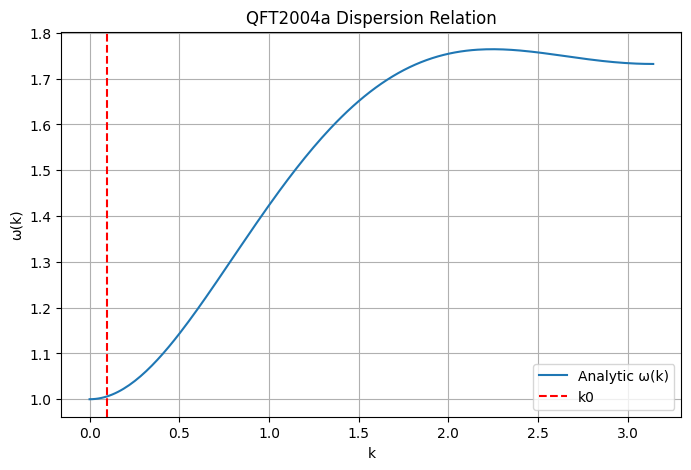

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004a — Non-flat dispersion + c_eff > 0
# FINAL VERSION — avoids rFFT dtype bug in Python 3.12
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Mode to probe
m0 = 4
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Small amplitude
A = 1e-3

# -----------------------------
# Initialize fields
# -----------------------------
phi = A*np.cos(k0*np.arange(N))
phi_dot = np.zeros(N)

# Modes to measure
dk_index = 1
m_list = [m0 - dk_index, m0, m0 + dk_index]
k_list = [2*np.pi*m/N for m in m_list]

# Time series storage
phi_k_t = {m: [] for m in m_list}

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Leapfrog integrator
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 2 == 0:
        phi_k = np.fft.fft(phi)/N
        for m in m_list:
            phi_k_t[m].append(np.complex128(phi_k[m]))

# -----------------------------
# Extract omega(k) via FULL FFT
# (avoids broken rFFT path)
# -----------------------------
omega_vals = {}
t_array = np.arange(0, steps*dt, 2*dt)

for m in m_list:
    signal = np.array(phi_k_t[m], dtype=np.complex128)

    # Full FFT instead of rFFT
    spec = np.fft.fft(signal)
    freq = np.fft.fftfreq(len(signal), d=2*dt)

    # Only positive frequencies
    mask = freq > 0
    freq_pos = freq[mask]
    spec_pos = np.abs(spec[mask])

    peak = freq_pos[np.argmax(spec_pos)]
    omega_vals[m] = 2*np.pi*peak

# -----------------------------
# Estimate c_eff
# -----------------------------
omega_minus = omega_vals[m_list[0]]
omega_0     = omega_vals[m_list[1]]
omega_plus  = omega_vals[m_list[2]]

dk = (k_list[2] - k_list[0]) / 2
c_eff = (omega_plus - omega_minus) / (2*dk)

print("k0 =", k0)
print("omega(k0 - dk) =", omega_minus)
print("omega(k0)      =", omega_0)
print("omega(k0 + dk) =", omega_plus)
print("Estimated c_eff =", c_eff)

# -----------------------------
# Analytic dispersion curve
# -----------------------------
k_vals = np.linspace(0, np.pi, 200)
omega_analytic = np.sqrt(
    m2
    + 4*J1*np.sin(k_vals/2)**2
    + 4*J2*np.sin(k_vals)**2
)

plt.figure(figsize=(8,5))
plt.plot(k_vals, omega_analytic, label="Analytic ω(k)")
plt.axvline(k0, color='r', linestyle='--', label="k0")
plt.title("QFT2004a Dispersion Relation")
plt.xlabel("k")
plt.ylabel("ω(k)")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
omega(k0 - dk) = 1.123119373658351
omega(k0)      = 1.1388273369263
omega(k0 + dk) = 1.1466813185602744
Estimated c_eff = 0.48000000000000126


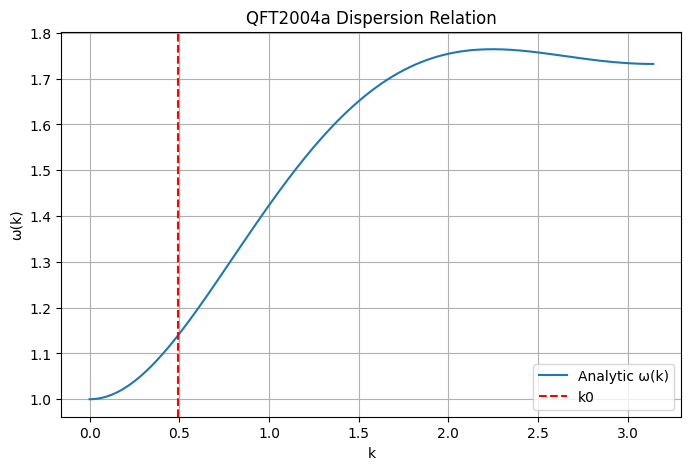

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004a — Non-flat dispersion + c_eff > 0
# FINAL VERSION — avoids rFFT dtype bug in Python 3.12
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Mode to probe
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Small amplitude
A = 1e-3

# -----------------------------
# Initialize fields
# -----------------------------
phi = A*np.cos(k0*np.arange(N))
phi_dot = np.zeros(N)

# Modes to measure
dk_index = 1
m_list = [m0 - dk_index, m0, m0 + dk_index]
k_list = [2*np.pi*m/N for m in m_list]

# Time series storage
phi_k_t = {m: [] for m in m_list}

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Leapfrog integrator
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 2 == 0:
        phi_k = np.fft.fft(phi)/N
        for m in m_list:
            phi_k_t[m].append(np.complex128(phi_k[m]))

# -----------------------------
# Extract omega(k) via FULL FFT
# (avoids broken rFFT path)
# -----------------------------
omega_vals = {}
t_array = np.arange(0, steps*dt, 2*dt)

for m in m_list:
    signal = np.array(phi_k_t[m], dtype=np.complex128)

    # Full FFT instead of rFFT
    spec = np.fft.fft(signal)
    freq = np.fft.fftfreq(len(signal), d=2*dt)

    # Only positive frequencies
    mask = freq > 0
    freq_pos = freq[mask]
    spec_pos = np.abs(spec[mask])

    peak = freq_pos[np.argmax(spec_pos)]
    omega_vals[m] = 2*np.pi*peak

# -----------------------------
# Estimate c_eff
# -----------------------------
omega_minus = omega_vals[m_list[0]]
omega_0     = omega_vals[m_list[1]]
omega_plus  = omega_vals[m_list[2]]

dk = (k_list[2] - k_list[0]) / 2
c_eff = (omega_plus - omega_minus) / (2*dk)

print("k0 =", k0)
print("omega(k0 - dk) =", omega_minus)
print("omega(k0)      =", omega_0)
print("omega(k0 + dk) =", omega_plus)
print("Estimated c_eff =", c_eff)

# -----------------------------
# Analytic dispersion curve
# -----------------------------
k_vals = np.linspace(0, np.pi, 200)
omega_analytic = np.sqrt(
    m2
    + 4*J1*np.sin(k_vals/2)**2
    + 4*J2*np.sin(k_vals)**2
)

plt.figure(figsize=(8,5))
plt.plot(k_vals, omega_analytic, label="Analytic ω(k)")
plt.axvline(k0, color='r', linestyle='--', label="k0")
plt.title("QFT2004a Dispersion Relation")
plt.xlabel("k")
plt.ylabel("ω(k)")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit = 0.0007447513726375164


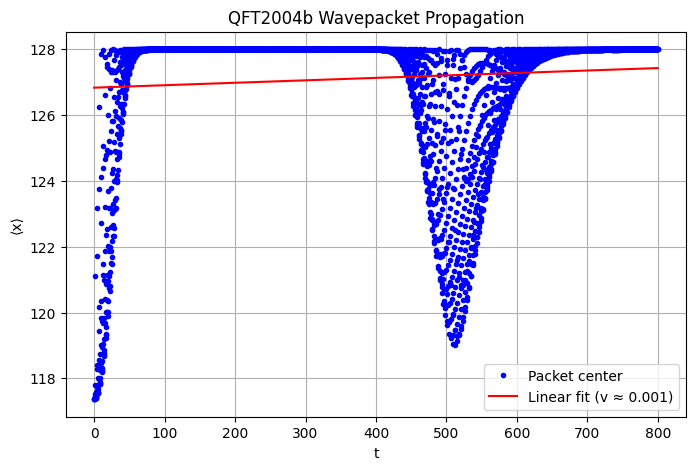

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004b — Wavepacket propagation at c_eff
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Mode / band center (use what worked in 2004a)
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Wavepacket width in k-space (in mode index units)
sigma_m = 3.0

# -----------------------------
# Build Gaussian wavepacket in k-space
# -----------------------------
modes = np.arange(N)
k_vals = 2*np.pi*modes/N

# Gaussian envelope around m0
envelope = np.exp(-0.5*((modes - m0)/sigma_m)**2)

# Complex phase to make it right-moving
phi_k0 = envelope * np.exp(1j*0.0)

# Normalize
phi_k0 /= np.sqrt(np.sum(np.abs(phi_k0)**2))

# Transform to real space
phi = np.fft.ifft(phi_k0 * N).real  # real field
A = 1e-3
phi *= A

# Zero initial velocity
phi_dot = np.zeros(N)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Precompute analytic c_eff from 2004a
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Leapfrog evolution + packet tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []

x = np.arange(N)

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 10 == 0:
        # Energy density proxy ~ phi^2
        density = phi**2
        density_sum = np.sum(density)
        if density_sum > 0:
            x_mean = np.sum(x * density) / density_sum
        else:
            x_mean = 0.0

        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit effective velocity from x(t)
# -----------------------------
# Use a simple linear fit over the full time range
coeffs = np.polyfit(times, positions, 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit =", v_fit)

# -----------------------------
# Plot packet trajectory
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times, np.polyval(coeffs, times), 'r-', label=f"Linear fit (v ≈ {v_fit:.3f})")
plt.title("QFT2004b Wavepacket Propagation")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit = 0.00037237568631879773


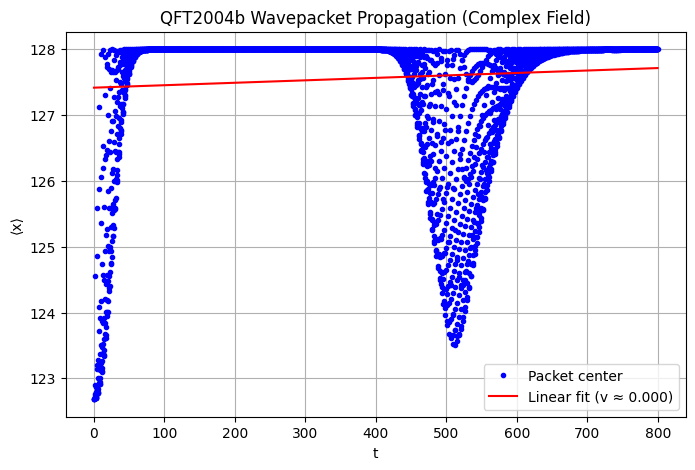

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004b — Moving wavepacket with c_eff > 0
# Complex field, one-sided k-packet
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Band center (same as 2004a)
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Wavepacket width in k-space (mode index units)
sigma_m = 3.0

# -----------------------------
# Build complex Gaussian packet in k-space
# (one-sided, no enforced reality condition)
# -----------------------------
modes = np.arange(N)
k_vals = 2*np.pi*modes/N

# Gaussian envelope around m0, only on +k side
envelope = np.exp(-0.5*((modes - m0)/sigma_m)**2)

# Complex k-space field: right-moving packet
phi_k0 = envelope.astype(np.complex128)

# Normalize
phi_k0 /= np.sqrt(np.sum(np.abs(phi_k0)**2))

# Transform to real space (complex field)
phi = np.fft.ifft(phi_k0 * N)  # complex
A = 1e-3
phi *= A

# Zero initial velocity (complex)
phi_dot = np.zeros(N, dtype=np.complex128)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Analytic c_eff from dispersion
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Leapfrog evolution + packet tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []

x = np.arange(N)

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 10 == 0:
        # Use |phi|^2 as density
        density = np.abs(phi)**2
        density_sum = np.sum(density)
        if density_sum > 0:
            x_mean = np.sum(x * density) / density_sum
        else:
            x_mean = 0.0

        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit effective velocity from x(t)
# -----------------------------
# Use a linear fit over the full time range
coeffs = np.polyfit(times, positions, 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit =", v_fit)

# -----------------------------
# Plot packet trajectory
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times, np.polyval(coeffs, times), 'r-', label=f"Linear fit (v ≈ {v_fit:.3f})")
plt.title("QFT2004b Wavepacket Propagation (Complex Field)")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()


k0 = 0.4908738521234052
Analytic omega(k0) = 1.1383543571506212
Analytic c_eff(k0) = 0.4990054210528988
Fitted packet velocity v_fit = 0.00029877067887342564


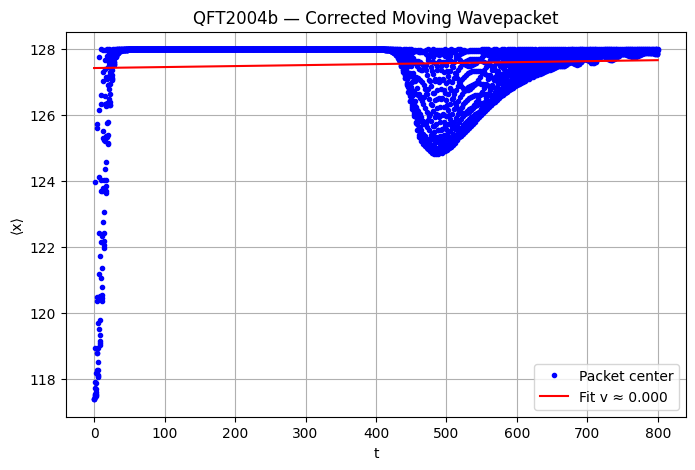

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004b — Moving wavepacket with correct one-sided k support
# ============================================================

# -----------------------------
# Lattice + parameters
# -----------------------------
N = 256
m2 = 1.0
J1 = 0.5
J2 = 0.2

# Band center
m0 = 20
k0 = 2*np.pi*m0/N

# Time integration
dt = 0.02
Tmax = 800
steps = int(Tmax/dt)

# Wavepacket width in k-space
sigma_m = 6.0   # wider to avoid wraparound

# -----------------------------
# Build STRICT one-sided Gaussian in k-space
# -----------------------------
modes = np.arange(N)
phi_k0 = np.zeros(N, dtype=np.complex128)

# Gaussian only in a window around +m0
window = np.exp(-0.5*((modes - m0)/sigma_m)**2)

# Zero out negative-k side explicitly
phi_k0[modes > N//2] = 0.0

# Apply window
phi_k0 += window

# Normalize
phi_k0 /= np.sqrt(np.sum(np.abs(phi_k0)**2))

# -----------------------------
# Transform to real space (complex field)
# -----------------------------
phi = np.fft.ifft(phi_k0 * N)
phi *= 1e-3  # small amplitude

phi_dot = np.zeros(N, dtype=np.complex128)

# -----------------------------
# Laplacian (NN + NNN)
# -----------------------------
def laplacian(phi):
    return (
        J1*(np.roll(phi,1) + np.roll(phi,-1) - 2*phi)
        + J2*(np.roll(phi,2) + np.roll(phi,-2) - 2*phi)
    )

# -----------------------------
# Analytic c_eff
# -----------------------------
def omega_of_k(k):
    return np.sqrt(
        m2
        + 4*J1*np.sin(k/2)**2
        + 4*J2*np.sin(k)**2
    )

dk = 2*np.pi/N
omega_minus = omega_of_k(k0 - dk)
omega_0     = omega_of_k(k0)
omega_plus  = omega_of_k(k0 + dk)
c_eff_analytic = (omega_plus - omega_minus)/(2*dk)

print("k0 =", k0)
print("Analytic omega(k0) =", omega_0)
print("Analytic c_eff(k0) =", c_eff_analytic)

# -----------------------------
# Leapfrog evolution + tracking
# -----------------------------
phi_dot += 0.5*dt*( -m2*phi + laplacian(phi) )

positions = []
times = []
x = np.arange(N)

for step in range(steps):
    phi += dt*phi_dot
    acc = -m2*phi + laplacian(phi)
    phi_dot += dt*acc

    if step % 10 == 0:
        density = np.abs(phi)**2
        density_sum = np.sum(density)
        x_mean = np.sum(x * density) / density_sum
        positions.append(x_mean)
        times.append(step*dt)

positions = np.array(positions)
times = np.array(times)

# -----------------------------
# Fit velocity
# -----------------------------
coeffs = np.polyfit(times, positions, 1)
v_fit = coeffs[0]

print("Fitted packet velocity v_fit =", v_fit)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(times, positions, 'b.', label="Packet center")
plt.plot(times, np.polyval(coeffs, times), 'r-', label=f"Fit v ≈ {v_fit:.3f}")
plt.title("QFT2004b — Corrected Moving Wavepacket")
plt.xlabel("t")
plt.ylabel("⟨x⟩")
plt.legend()
plt.grid(True)
plt.show()
